In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Détection des contours

# Méthode 1 : Le threshold.

## 1ère étape : Déterminer le seuil de séparation clair / sombre.

On va analyser la dispersion des valeurs de gris des pixels. L'idée est de séparer les pixels clairs des pixels sombre de l'image.

Pour cela, on va aplatir notre matrice de gris pour obtenir une liste qui contient la nuance de gris (0 à 255) pour chaque pixel.

On va ensuite analyser la dispersion des valeurs avec un histogramme pour séparer les tons clairs des sombres.

/var/folders/3c/1_03mt2j3nd473f8ks3p07n80000gn/T/ipykernel_78635/1428219451.py:6: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(gray.flatten(), 256, [0,256]) # flatten permet d'aplatir la matrice en un vecteur


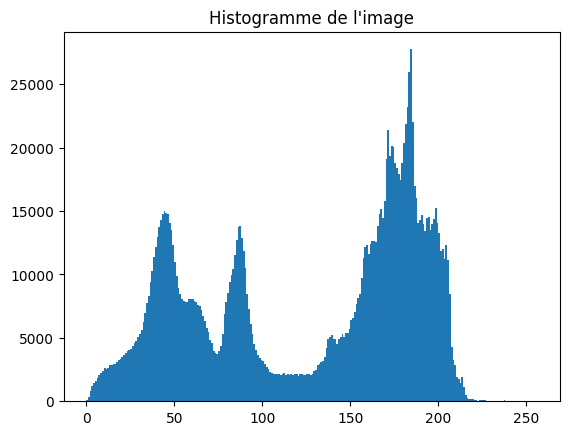

In [2]:
# Charger l'image
img = cv2.imread("images/normandie.jpg", cv2.IMREAD_COLOR)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Afficher l'histogramme
plt.hist(gray.flatten(), 256, [0,256]) # flatten permet d'aplatir la matrice en un vecteur
plt.title("Histogramme de l'image")
plt.show()

Déterminer la valeur de gris qui contient le moins de pixel entre les deux modes permettra de déterminer le seuil de binarisation.

In [3]:
counts, bins = np.histogram(gray.flatten(), bins=256, range=(0, 256))
pic_1 = 65
pic_2 = 140
vallee = counts[pic_1:pic_2]
index_du_minimum = np.argmin(vallee)
seuil = index_du_minimum + pic_1
seuil

np.int64(120)

Notre seuil est 110. 

Mais on peut aussi trouver le seuil directement avec OpenCV sans tracer l'histogramme. 

In [4]:
seuil_calcule, thresh_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
seuil_calcule

117.0

On obtient 117 avec la méthode OTSU d'OpenCV, ce qui est très proche du seuil qu'on a déterminé avec l'histogramme.

## 2éme étape : Binariser notre image en pixel blanc et noir par rapport au seuil.

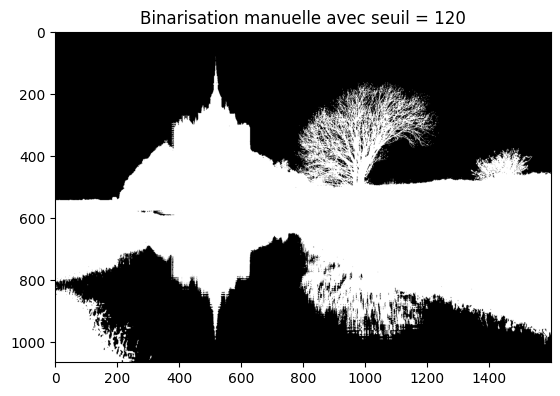

In [5]:

image_binarisée = np.where(gray < seuil, 255, 0).astype('uint8')

plt.imshow(image_binarisée, cmap='gray')
plt.title(f"Binarisation manuelle avec seuil = {seuil}")
plt.show()

On obtient une image binarisée (0 ou 255 pour chaque pixel)

Le contraste va permettre de détecter les bordures grâce à la méthode fincContours. 

La méthode findContours parcours 1 à 1 les pixels de gauche à droite et de haut en bas tant qu'elle ne croise pas de pixel 255.

Dès qu'elle croise un pixel 255, elle sait qu'elle fait face au bord d'une forme. Elle passe en mode "contours". Elle cherche parmi les 8 voisins le prochain pixel 255. Une fois de retour au pixel de départ, elle a terminer de contourner une forme, annote chacun des pixel du contours et continue de parcourir chaque pixel de gauche à droite et de haut en bas, en revenant ou elle s'était arrêtée.

## 3ème étape : Tracer les contours

In [ ]:
contours, _ = cv2.findContours(image_binarisée, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

Mode : 
| Constante | Description simple |
| :--- | :--- |
| **`cv2.RETR_LIST`** | **"Tout en vrac"** : Récupère tous les contours sans établir de hiérarchie entre eux. |
| **`cv2.RETR_EXTERNAL`** | **"Seulement l'extérieur"** : Ignore les trous ou les contours imbriqués pour ne garder que la silhouette globale. |
| **`cv2.RETR_CCOMP`** | **"Extérieur vs Intérieur"** : Organise les contours sur deux niveaux (les objets et leurs trous respectifs). |
| **`cv2.RETR_TREE`** | **"Arbre complet"** : Reconstruit toute la généalogie des formes (qui est à l'intérieur de quoi). |

Method : Grace à APPROX_SIMPLE, chaque contours est défini par moins de points. Ici le premier contours est défini par 32 pts.

In [7]:
contours[0].shape

(4, 1, 2)

## 4ème étape : Tracer les contours

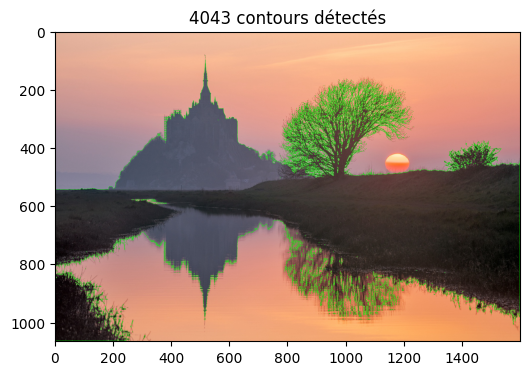

In [10]:
cv2.drawContours(img, contours, -1, (0, 255, 0), 1)
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"{len(contours)} contours détectés")
plt.show()

On a détecté 61 contours sur l'image, c'est beaucoup. 

## Optimisation

Paradoxalement, en réduisant la qualité de l'image, en la flouttant par exemple, on parvient à améliorer notre détection. 

En effet, le flou réduit le bruit de l'image et lisse le contraste.

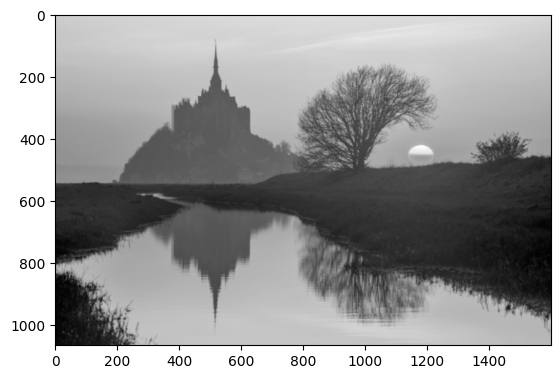

In [9]:
gray_blurred = cv2.GaussianBlur(gray, (7, 7), 0)
plt.imshow(gray_blurred, cmap='gray')

In [10]:
image_binarisée = np.where(gray_blurred < seuil, 255, 0).astype('uint8')
contours, _ = cv2.findContours(image_binarisée, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

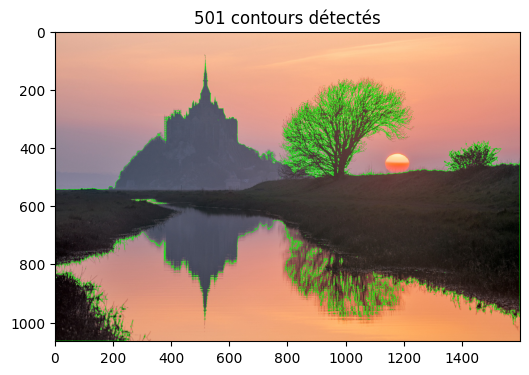

In [11]:
cv2.drawContours(img, contours, -1, (0, 255, 0), 1)
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"{len(contours)} contours détectés")
plt.show()

On peut s'amuser à tracer les contours sur l'image réelle, puis sur des matrices zéros, donc des fond noirs.

La deuxièmé image trace uniquement les contours et la troisième les rempli.

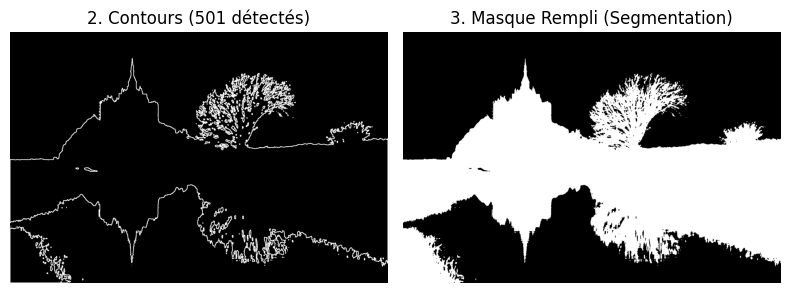

In [14]:
# Préparation des masques
mask_traits = np.zeros(gray.shape, dtype="uint8")
mask_rempli = np.zeros(gray.shape, dtype="uint8")

# Dessin sur les masques
cv2.drawContours(mask_traits, contours, -1, 255, 2)  # Traits
cv2.drawContours(mask_rempli, contours, -1, 255, -1) # Rempli

# Création de la figure avec 3 lignes et 1 colonne
fig, ax = plt.subplots(1, 2, figsize=(8, 18))

# 2. Contours (Traits)
ax[0].imshow(mask_traits, cmap='gray')
ax[0].set_title(f"2. Contours ({len(contours)} détectés)")
ax[0].axis('off')

# 3. Formes (Rempli)
ax[1].imshow(mask_rempli, cmap='gray')
ax[1].set_title("3. Masque Rempli (Segmentation)")
ax[1].axis('off')

plt.tight_layout()
plt.show()

Bien que cette méthode de seuillage binaire soit le fondement historique de la vision industrielle et reste largement utilisée aujourd'hui pour des tâches simples et contrôlées (lecture de codes-barres, tri de pièces sur tapis roulant), elle montre ses limites dès que l'environnement devient complexe : elle ne distingue pas les objets par leur nature, mais uniquement par leur contraste.

# Méthode 2 : Le gradient

## 1ère étape : La méthode de Sobel

Alors que le seuillage (OTSU) cherche des masses, le gradient cherche des ruptures. 
C'est l'outil mathématique qui permet de dire : "Ici, la couleur change brutalement, donc il y a un contours".

In [15]:
img = cv2.imread('images/normandie.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blurred = cv2.GaussianBlur(gray, (15, 15), 0)

On calcule les gradients x et y

In [16]:

grad_x = cv2.Sobel(gray_blurred, cv2.CV_32F, 1, 0, ksize=3) # Détecte bords verticaux
grad_y = cv2.Sobel(gray_blurred, cv2.CV_32F, 0, 1, ksize=3) # Détecte bords horizontaux

On calcule la magnitude (on prend la racine de la somme des carrés)

In [17]:
mag = np.sqrt(grad_x**2 + grad_y**2)

On normalise entre 0 et 255 (pour retrouver nos nuances de gris)

In [18]:
mag_norm = np.uint8(cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX))
_, thresh_binary = cv2.threshold(mag_norm, 46, 255, cv2.THRESH_BINARY)

In [19]:
contours, _ = cv2.findContours(thresh_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
len(contours)

634

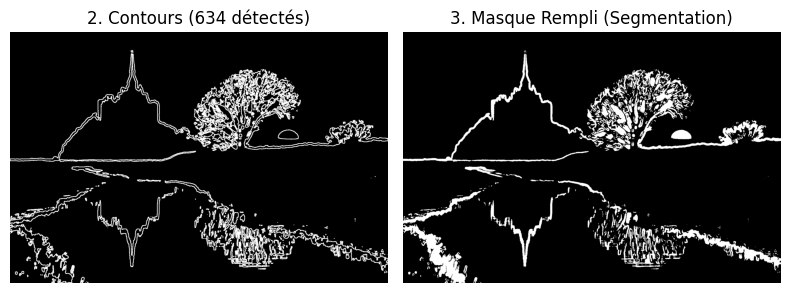

In [20]:
# Préparation des masques
mask_traits = np.zeros(gray.shape, dtype="uint8")
mask_rempli = np.zeros(gray.shape, dtype="uint8")

# Dessin sur les masques
cv2.drawContours(mask_traits, contours, -1, 255, 2)  # Traits
cv2.drawContours(mask_rempli, contours, -1, 255, -1) # Rempli

# Création de la figure avec 3 lignes et 1 colonne
fig, ax = plt.subplots(1, 2, figsize=(8, 18))


# 2. Contours (Traits)
ax[0].imshow(mask_traits, cmap='gray')
ax[0].set_title(f"2. Contours ({len(contours)} détectés)")
ax[0].axis('off')

# 3. Formes (Rempli)
ax[1].imshow(mask_rempli, cmap='gray')
ax[1].set_title("3. Masque Rempli (Segmentation)")
ax[1].axis('off')

plt.tight_layout()
plt.show()

Pour finir, on peut utiliser la méthode Canny qui utilise Sobel mais qui affine l'analyse, notamment en utilisant 2 seuils au lieu d'un.

Si < seuil 1, le gradient est très faible, pas de contours.
Si > seuil 2, le gradient est très fort, c'est un contours. 
Si > seuil 1 et < seuil 2, on regarde si l'un des voisins est > seuil 2, si oui alors contours.

In [21]:
v = np.median(gray_blurred)
sigma = 0.33 # On définit une marge de 33% autour de la médiane

seuil_bas = int(max(0, (1.0 - sigma) * v))
seuil_haut = int(min(255, (1.0 + sigma) * v))

edges = cv2.Canny(gray_blurred, seuil_bas, seuil_haut)

In [22]:
# Canny demande deux seuils (bas et haut)
# Typiquement, on conseille un ratio de 1:2 ou 1:3
edges_canny = cv2.Canny(gray_blurred, seuil_bas, seuil_haut)

# On cherche les contours sur Canny
contours_canny, _ = cv2.findContours(edges_canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

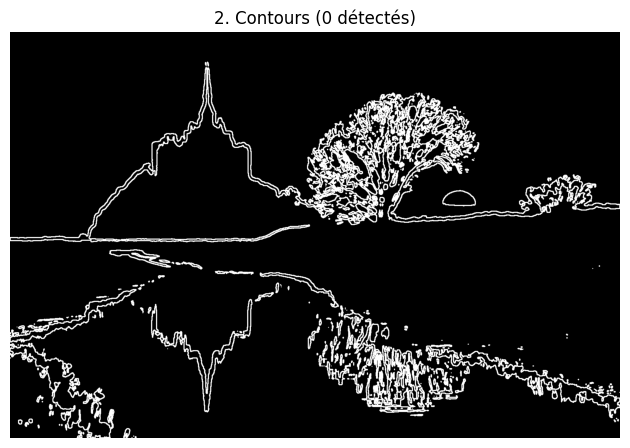

In [23]:
mask_rempli = np.zeros(gray.shape, dtype="uint8")

# Dessin sur les masques
cv2.drawContours(mask_traits, contours_canny, -1, 255, 2)  # Traits

plt.imshow(mask_traits, cmap='gray')
plt.title(f"2. Contours ({len(contours_canny)} détectés)")
plt.axis('off')

plt.tight_layout()
plt.show()